In [1]:
from gins_partials import hard_code_fortran90
from numpy import arange

print(hard_code_fortran90(variable_name="love_numbers", array_to_write=arange(36).reshape((3, 4, 3)), max_line_length=50))

 real(kind=DP), dimension(3,4,3) :: love_numbers

 love_numbers = reshape( (/ &
    +0.0000E+00, +1.2000E+01, +2.4000E+01,&
       +3.0000E+00, +1.5000E+01, +2.7000E+01,&
       +6.0000E+00, +1.8000E+01, +3.0000E+01,&
       +9.0000E+00, +2.1000E+01, +3.3000E+01,&
       +1.0000E+00, +1.3000E+01, +2.5000E+01,&
       +4.0000E+00, +1.6000E+01, +2.8000E+01,&
       +7.0000E+00, +1.9000E+01, +3.1000E+01,&
       +1.0000E+01, +2.2000E+01, +3.4000E+01,&
       +2.0000E+00, +1.4000E+01, +2.6000E+01,&
       +5.0000E+00, +1.7000E+01, +2.9000E+01,&
       +8.0000E+00, +2.0000E+01, +3.2000E+01,&
       +1.1000E+01, +2.3000E+01, +3.5000E+01, /), (/ 3,4,3 /) )
    
    


19.18849259025243


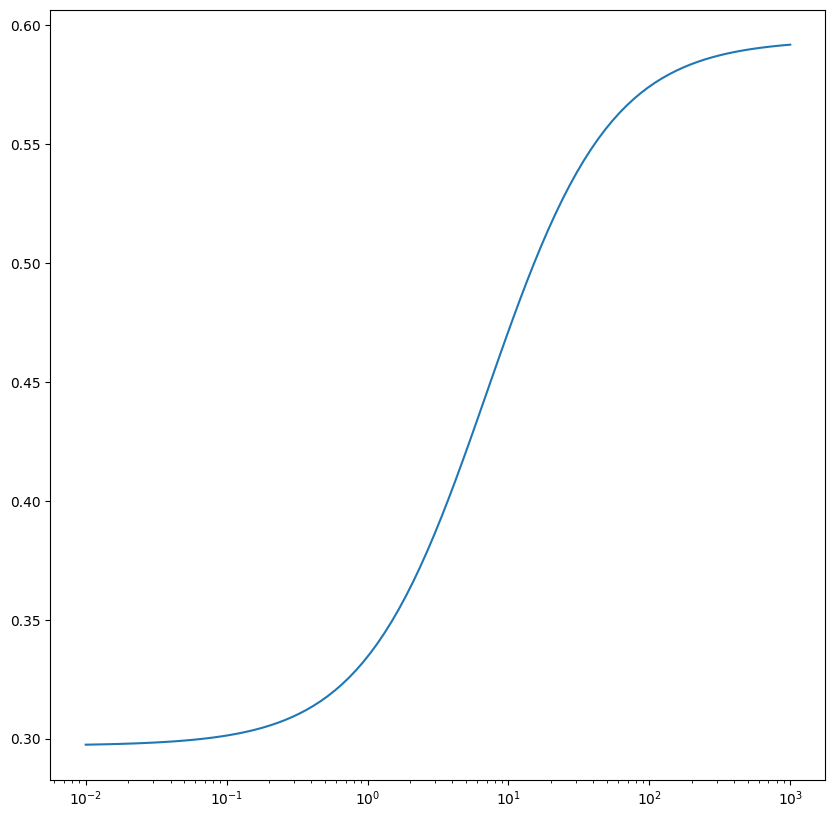

In [2]:
from numpy import logspace, exp, log, pi
from matplotlib.pyplot import semilogx, figure

ELASTIC_K2 = 0.297
RELAXED_K2 = 2 * ELASTIC_K2 - 7e-3j
sigmoid = lambda x: (1 + exp(-x)) ** (-1)
tau_m_sup = lambda alpha, delta: ((3e-4) ** (-alpha) + alpha * 312 * delta / (delta + 1)) ** (
    1.0 / alpha
)
SECONDS_PER_YEAR = 86400 * 365


def log_sigmoid(alpha: float, delta: float, omega: float) -> float:

    t = tau_m_sup(alpha=alpha, delta=delta) / SECONDS_PER_YEAR
    a = 10 * (log(t) - log(3e-4)) ** (-1)
    period = 2 * pi / omega

    return sigmoid(x=a * (log(period / t)))


k2_model = lambda alpha, delta, omega: ELASTIC_K2 + (RELAXED_K2 - ELASTIC_K2) * log_sigmoid(
    alpha=alpha, delta=delta, omega=omega
)

period_tab = logspace(start=-2, stop=3, num=100, base=10)
omega_tab = 2 * pi / (period_tab)
print(tau_m_sup(alpha=0.2, delta=5) / SECONDS_PER_YEAR)
figure(figsize=(10, 10))
semilogx(period_tab, [k2_model(alpha=0.2, delta=2, omega=omega).real for omega in omega_tab])